In [1]:
# FOR DEBUG
DEBUG = False
TRAINING_SAMPLES = 15000 if not DEBUG else 1500
VALIDATION_SAMPLES = 10000 if not DEBUG else 1000
FINAL_TRAINING = 20000 if not DEBUG else 2000
FULL_TRAINING = 50000 if not DEBUG else 5000

# Assignment: Classification of Fashion Items

In this assignment, you will classify fashion articles from the [MNIST fashion dataset](https://github.com/zalandoresearch/fashion-mnist) using two different tools: a k-nearest neighbor classifier and a dense neural network (multilayer perceptron). The relevant material for this assignment is covered in lectures 8 and 9. The assignment instructions are provided on Canvas.

## Boilerplate Notebook Code

Below, you find the boilerplate code that you have to use for the assignment, including basic instructions.
Note that you may need to change the dependency installation procedure.
Debug by removing the `%%capture` line.
If you use a [virtual environment](https://docs.python.org/3/library/venv.html), make sure you can set the notebook's kernel accordingly (assuming your virtual environment is called `venv`):

```
pip3 install ipykernel
python -m ipykernel install --user --name=venv
```

Then, also remove the flags `--user -Iv` below.

In [2]:
import numpy as np
np.random.seed(42)  # Set the random seed for reproducible results

In [3]:
# Load the Fashion MNIST dataset (this may take a while)

import sklearn.datasets

data = sklearn.datasets.fetch_openml("Fashion-MNIST")

print(data.DESCR)

**Author**: Han Xiao, Kashif Rasul, Roland Vollgraf  
**Source**: [Zalando Research](https://github.com/zalandoresearch/fashion-mnist)  
**Please cite**: Han Xiao and Kashif Rasul and Roland Vollgraf, Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms, arXiv, cs.LG/1708.07747  

Fashion-MNIST is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Fashion-MNIST is intended to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits. 

Raw data available at: https://github.com/zalandoresearch/fashion-mnist

### Target classes
Each training and test example is assigned to one of the following labels:
Label  Description  
0  T-shirt/top  
1  Trouser  
2  Pullover  
3  Dress  
4  

In [4]:
# Split the data into training, (validation), and test set

from sklearn.model_selection import train_test_split


Xtrain, Xtest, ytrain, ytest = train_test_split(data.data, data.target, test_size=0.25, random_state=1)

# You may alternatively skip this / have a combined Xtrain and Xval here and instead use cross-validation below
Xtest, Xval, ytest, yval = train_test_split(Xtest, ytest, test_size=0.5, random_state=1)
Xtrain =  np.asarray(Xtrain)
Xtest =  np.asarray(Xtest)
Xval =  np.asarray(Xval)
ytrain = ytrain.astype(int)
yval = yval.astype(int)
ytest = ytest.astype(int)


# Note! Do not touch the test data until the very end!

print(f"Training set size X   : {Xtrain.shape}")
print(f"Training set size y   : {ytrain.shape}")
print(f"Validation set size X : {Xval.shape}")
print(f"Validation set size y : {yval.shape}")
print(f"Test set size X       : {Xtest.shape}")
print(f"Test set size y       : {ytest.shape}")
print(f"Output classes        : {set(ytrain)}")

Training set size X   : (52500, 784)
Training set size y   : (52500,)
Validation set size X : (8750, 784)
Validation set size y : (8750,)
Test set size X       : (8750, 784)
Test set size y       : (8750,)
Output classes        : {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [5]:
# Preprocess the data

import sklearn.preprocessing

print(f"Before preprocessing, test data       : "
      f"min = {np.min(Xtrain):.1f}, "
      f"max = {np.max(Xtrain):.1f}, "
      f"mean = {np.mean(Xtrain):.1f}, "
      f"std = {np.std(Xtrain):.1f}")
print(f"Before preprocessing, validation data : "
      f"min = {np.min(Xval):.1f}, "
      f"max = {np.max(Xval):.1f}, "
      f"mean = {np.mean(Xval):.1f}, "
      f"std = {np.std(Xval):.1f}")
print(f"Before preprocessing, test data       : "
      f"min = {np.min(Xtest):.1f}, "
      f"max = {np.max(Xtest):.1f}, "
      f"mean = {np.mean(Xtest):.1f}, "
      f"std = {np.std(Xtest):.1f}")

scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(-1, 1))
scaler.fit(Xtrain)  # Every statistic we compute is found on the training data!

Xtrain = scaler.transform(Xtrain)
Xval = scaler.transform(Xval)
# TODO: If you do cross-validation, you must redo this on the training data in
#       each cross-validation loop, and then transform the validation data as
#       well!
Xtest = scaler.transform(Xtest)

print(f"After preprocessing, test data        : "
      f"min = {np.min(Xtrain):.1f}, "
      f"max = {np.max(Xtrain):.1f}, "
      f"mean = {np.mean(Xtrain):.1f}, "
      f"std = {np.std(Xtrain):.1f}")
print(f"After preprocessing, validation data  : "
      f"min = {np.min(Xval):.1f}, "
      f"max = {np.max(Xval):.1f}, "
      f"mean = {np.mean(Xval):.1f}, "
      f"std = {np.std(Xval):.1f}")
print(f"After preprocessing, test data        : "
      f"min = {np.min(Xtest):.1f}, "
      f"max = {np.max(Xtest):.1f}, "
      f"mean = {np.mean(Xtest):.1f}, "
      f"std = {np.std(Xtest):.1f}")

# TODO: Try to apply other preprocessing, e.g. the
#       sklearn.preprocessing.StandardScaler(), and see if the results improve.

Before preprocessing, test data       : min = 0.0, max = 255.0, mean = 72.9, std = 89.9
Before preprocessing, validation data : min = 0.0, max = 255.0, mean = 73.5, std = 90.3
Before preprocessing, test data       : min = 0.0, max = 255.0, mean = 72.9, std = 90.1
After preprocessing, test data        : min = -1.0, max = 1.0, mean = -0.4, std = 0.7
After preprocessing, validation data  : min = -1.0, max = 1.2, mean = -0.4, std = 0.7
After preprocessing, test data        : min = -1.0, max = 1.7, mean = -0.4, std = 0.7


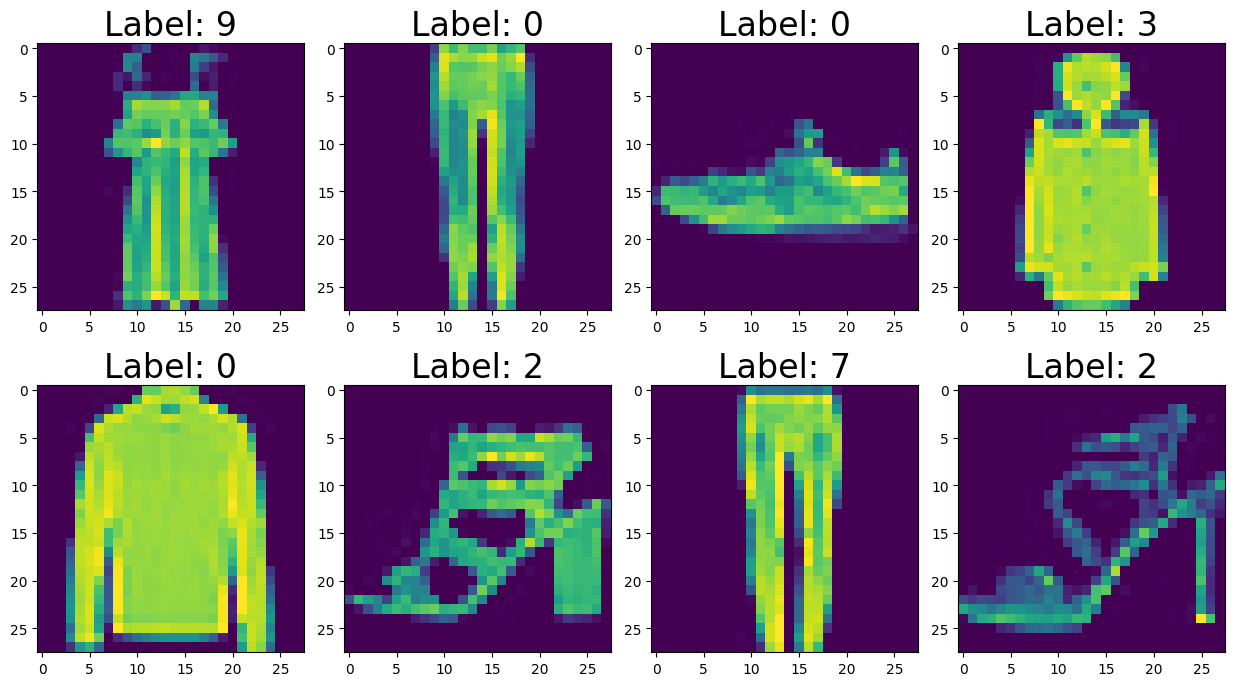

In [6]:
# Plot a few images

import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(12, 7.75))
fig.subplots_adjust(top=0.995,
                    bottom=0.115,
                    left=0.005,
                    right=0.995,
                    wspace=0.15,
                    hspace=0.005)

plot_array = (2, 4)
ax = [[None] * plot_array[1]] * plot_array[0]
it = 0
for i in range(plot_array[0]):
    for j in range(plot_array[1]):
        ax[i][j] = plt.subplot2grid((2, 4), (i, j), rowspan=1, colspan=1)
        ax[i][j].imshow(Xtrain[it, :].reshape((28, 28)))
        ax[i][j].set_title(f"Label: {ytrain[it]}", fontsize=24)
        it += 1

### The $k$-NN model

You have to implement the $k$-NN classifier yourself. The below implementation uses the scikit-learn implementation of the $k$-NN classifier, but you need to do it yourself. Also, perform a hyper-parameter search for the optimal number of neighbors, $k$.

In [7]:
import numpy as np

class MyKNN:
    def __init__(self, n_neighbors=5, metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def _distance(self, x):
        if self.metric == 'manhattan':
            return np.sum(np.abs(self.X_train - x), axis=1)
        else:  # Euclidean distance
            return np.sqrt(np.sum((self.X_train - x)**2, axis=1))

    def predict_one(self, x):
        dists = self._distance(x)
        idx = np.argsort(dists)[:self.n_neighbors]
        neighbors = self.y_train[idx]
        # majority vote
        return np.bincount(neighbors.astype(int)).argmax()

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self.predict_one(x) for x in X])

    def score(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)


In [8]:
# Perform grid search to find the number of neighbours, K

k_max = 10  # Set the maximum number of neighbours considered

# TODO: Perform a hyper-parameter search for the parameter k here. Either use
#       the validation dataset, or optionally use cross-validation here.
k = 1

errs_val = []
k_values = range(1, k_max + 1)

for k in k_values:
    model = MyKNN(n_neighbors=k, metric='manhattan')
    model.fit(Xtrain[:TRAINING_SAMPLES, :], ytrain[:TRAINING_SAMPLES])
    err = model.score(Xval[:VALIDATION_SAMPLES, :], yval[:VALIDATION_SAMPLES])
    errs_val.append(err)
    print(f"Testing k={k}: validation accuracy {err:.4f}")

# TODO: The distance computations may take a long time. Play with different
#       amounts of data here to see what is feasible for you. Get it to work
#       on a small amount of data, and then run for a longer time with more
#       data. You may not be able to use all data with the k-NN method,
#       depending on the computer you have for this.

k = model.n_neighbors
print(f"Number of neighbors: k={k}, validation accuracy: {err}")
print("Grid search done!")

Testing k=1: validation accuracy 0.8275
Testing k=2: validation accuracy 0.8234
Testing k=3: validation accuracy 0.8361
Testing k=4: validation accuracy 0.8381
Testing k=5: validation accuracy 0.8383
Testing k=6: validation accuracy 0.8413
Testing k=7: validation accuracy 0.8387
Testing k=8: validation accuracy 0.8390
Testing k=9: validation accuracy 0.8408
Testing k=10: validation accuracy 0.8401
Number of neighbors: k=10, validation accuracy: 0.8401142857142857
Grid search done!


Text(0, 0.5, 'Validation Accuracy')

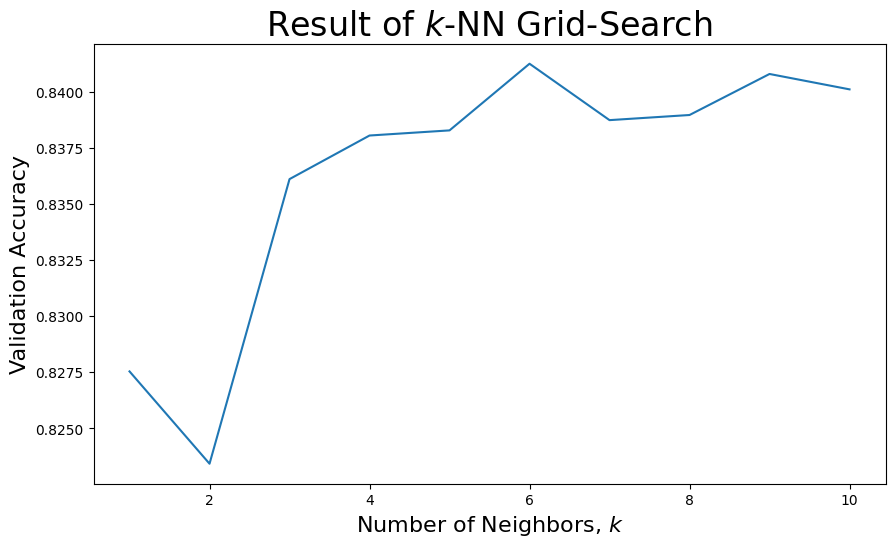

In [9]:
# Plot the accuracy curve as a function of k

fig = plt.figure(figsize=(8, 5))
fig.subplots_adjust(top=0.995,
                    bottom=0.115,
                    left=0.005,
                    right=0.995,
                    wspace=0.15,
                    hspace=0.005)

ax0 = plt.subplot2grid((1, 1), (0, 0), rowspan=1, colspan=1)
ax0.plot(range(1, len(errs_val) + 1), errs_val)
ax0.set_title("Result of $k$-NN Grid-Search", fontsize=24)
ax0.set_xlabel("Number of Neighbors, $k$", fontsize=16)
ax0.set_ylabel("Validation Accuracy", fontsize=16)

In [10]:
# Train the final k-NN model with the best value for k

k_best = np.argmax(errs_val) + 1
print(f"The best value was {errs_val[k_best - 1]}, found using k={k_best}.")

model_knn = MyKNN(n_neighbors=k_best, metric='manhattan')
model_knn.fit(Xtrain[:FINAL_TRAINING, :], ytrain[:FINAL_TRAINING])
err = model_knn.score(Xval[:VALIDATION_SAMPLES, :], yval[:VALIDATION_SAMPLES])
print(f"Final validation accuracy: {err}")

The best value was 0.8412571428571428, found using k=6.
Final validation accuracy: 0.8464


### The neural network model

We will use the neural networks (multilayer perceptrons) implemented in scikit-learn. You need to find the optimal number of layers, the number of neurons in each of the layers, and any other hyper-parameters that may be relevant. Again, you may first execute the search with a small subset of the data to make sure it works reasonably well.

In [11]:
# Create the NN classifier

import sklearn.neural_network
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Preprocessing
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xval_scaled = scaler.transform(Xval)
Xtest_scaled = scaler.transform(Xtest)

# TODO: Perform grid search to find the number of layers, the number of neurons
#       in each layer, etc.

# TODO: Try different numbers of layers and different numbers of neurons.

# TODO: You may have to test other hyper-parameters than just the number of
#       layers and the number of artificial neurons in each layer. It might be
#       worth varying the learning rate as well, for instance.

errs_val = {}

hidden_layer_options = [
    (256, 128, 64),
    (200, 100),
    (300, 200, 100),
    (128, 64),
    (400, 200)
]
learning_rates = [0.0005, 0.001, 0.002, 0.005]

best_acc = 0
best_params = None

for hidden_layer_sizes in hidden_layer_options:
    for lr in learning_rates:
        model = sklearn.neural_network.MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            learning_rate_init=lr,
            max_iter=1000,
            early_stopping=True,
            random_state=42
        )
        model.fit(Xtrain_scaled[:FINAL_TRAINING], ytrain[:FINAL_TRAINING])
        err = model.score(Xval_scaled, yval)
        print(f"Hidden layer sizes: {hidden_layer_sizes}, lr={lr:.4f}, validation accuracy: {err:.4f}")
        errs_val[(hidden_layer_sizes, lr)] = err

        if err > best_acc:
            best_acc = err
            best_params = (hidden_layer_sizes, lr)

print("Grid search done!")
print(f"Best configuration: {best_params}, validation accuracy: {best_acc:.4f}")

Hidden layer sizes: (256, 128, 64), lr=0.0005, validation accuracy: 0.8770
Hidden layer sizes: (256, 128, 64), lr=0.0010, validation accuracy: 0.8751
Hidden layer sizes: (256, 128, 64), lr=0.0020, validation accuracy: 0.8713
Hidden layer sizes: (256, 128, 64), lr=0.0050, validation accuracy: 0.8679
Hidden layer sizes: (200, 100), lr=0.0005, validation accuracy: 0.8719
Hidden layer sizes: (200, 100), lr=0.0010, validation accuracy: 0.8690
Hidden layer sizes: (200, 100), lr=0.0020, validation accuracy: 0.8734
Hidden layer sizes: (200, 100), lr=0.0050, validation accuracy: 0.8722
Hidden layer sizes: (300, 200, 100), lr=0.0005, validation accuracy: 0.8733
Hidden layer sizes: (300, 200, 100), lr=0.0010, validation accuracy: 0.8727
Hidden layer sizes: (300, 200, 100), lr=0.0020, validation accuracy: 0.8726
Hidden layer sizes: (300, 200, 100), lr=0.0050, validation accuracy: 0.8689
Hidden layer sizes: (128, 64), lr=0.0005, validation accuracy: 0.8711
Hidden layer sizes: (128, 64), lr=0.0010, 

The best value was 0.8780571428571429, found using layer sizes: (400, 200) and learning rate 0.0005


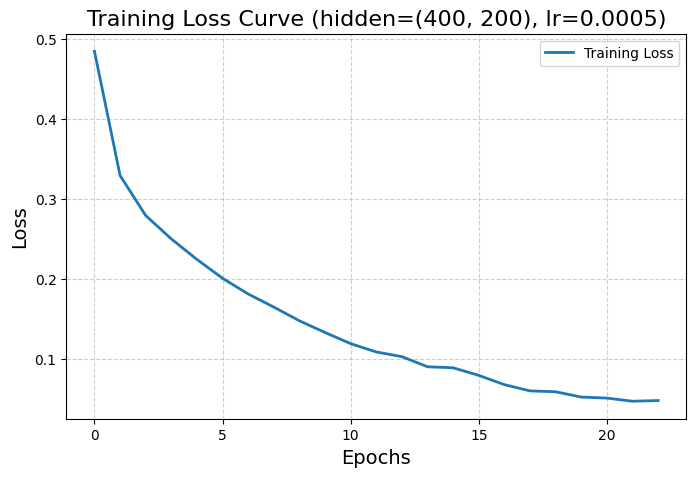

In [12]:
# Train the final model using the best layer sizes
hidden_layer_sizes_best, best_lr = best_params
print(f"The best value was {best_acc}, found using layer sizes: {hidden_layer_sizes_best} and learning rate {best_lr}")

model_ann = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes_best,
    alpha=0.0001,
    batch_size='auto',
    learning_rate_init=best_lr,
    max_iter=1000,
    early_stopping=True,
    random_state=42,
)

model_ann.fit(Xtrain_scaled[:FULL_TRAINING, :], ytrain[:FULL_TRAINING])

# Plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(model_ann.loss_curve_, label="Training Loss", linewidth=2)
plt.title(f"Training Loss Curve (hidden={hidden_layer_sizes_best}, lr={best_lr})", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Once we have selected our final model, we can compute the test error on the final models as the last thing we do. Make sure to only do this at the very end, after you have selected the best models you can find.

In [13]:
# Evaluate the final model on all the data sets, including the test data. We
# only evaluate the test data once, and as the last thing we do. If you train
# another model after this, based on the performance on the test data, then your
# test data is effectively a validation dataset, and you no longer have a test
# dataset. (Or, if you keep your test data set, then your results are biased and
# by that unreliable.)
print(f"k-NN model training data accuracy  : {model_knn.score(Xtrain, ytrain)}")
print(f"k-NN model validation data accuracy: {model_knn.score(Xval, yval)}")
if True:  # Change this to True as the very last thing you do!
    print(f"k-NN model test data accuracy      : " f"{model_knn.score(Xtest, ytest)}")

print(f"Training accuracy:   {model_ann.score(Xtrain_scaled, ytrain):.4f}")
print(f"Validation accuracy: {model_ann.score(Xval_scaled, yval):.4f}")
if True:  # Change this to True as the very last thing you do!
    print(f"Test accuracy:       {model_ann.score(Xtest_scaled, ytest):.4f}")

k-NN model training data accuracy  : 0.8565714285714285
k-NN model validation data accuracy: 0.8464
k-NN model test data accuracy      : 0.8450285714285715
Training accuracy:   0.9574
Validation accuracy: 0.8929
Test accuracy:       0.8937
